<a href="https://colab.research.google.com/github/azraisik/yapay-sinir-aglari/blob/sena%2Fveri-isleme/SENA_VERI_ON_ISLEME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
#1.VERİ SETİ OKUMA

import pandas as pd
import numpy as np

dosya_yolu = 'Incident_Management_CSV.csv'


df = pd.read_csv(dosya_yolu, sep=';') #veri setimiz noktalı virgül ile ayrılıyor

print("Veri seti yüklendi")
print("-" * 50)
print(f"Veri setinin boyutu: {df.shape[0]} Satır, {df.shape[1]} Sütun")

Veri seti yüklendi
--------------------------------------------------
Veri setinin boyutu: 242901 Satır, 11 Sütun


In [33]:
#2.VERİ SETİNİN ANALİZİ

print("--- Veri Setinin ilk 5 satırı ---")
display(df.head())

print("\n-- Veri Tipleri ve Eksik Veri Özeti ---")
df.info()

--- Veri Setinin ilk 5 satırı ---


,Case ID,Variant,Priority,Reporter,Timestamp,Event,Issue Type,Resolver,Report Channel,Short Description,Customer Satisfaction
0,INC0001,Variant 4,Medium,Alice,17/11/2023 11:17,Ticket created,Performance Issue,NaN,Website,Application crash,3
1,INC0001,Variant 4,Medium,Alice,17/11/2023 13:30,Ticket assigned to level 1 support,Performance Issue,Sam,Website,Application crash,3
2,INC0001,Variant 4,Medium,Alice,17/11/2023 14:06,WIP - level 1 support,Performance Issue,Sam,Website,Application crash,3
3,INC0001,Variant 4,Medium,Alice,17/11/2023 16:52,Level 1 escalates to level 2 support,Performance Issue,Michael,Website,Application crash,3
4,INC0001,Variant 4,Medium,Alice,17/11/2023 18:07,WIP - level 2 support,Performance Issue,Emma,Website,Application crash,3



-- Veri Tipleri ve Eksik Veri Özeti ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242901 entries, 0 to 242900
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Case ID                242901 non-null  object
 1   Variant                242901 non-null  object
 2   Priority               242901 non-null  object
 3   Reporter               242901 non-null  object
 4   Timestamp              242901 non-null  object
 5   Event                  242901 non-null  object
 6   Issue Type             242901 non-null  object
 7   Resolver               146405 non-null  object
 8   Report Channel         242901 non-null  object
 9   Short Description      242901 non-null  object
 10  Customer Satisfaction  242901 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 20.4+ MB


In [34]:
#3.EKSİK VERİ (NaN) TESPİTİ

print("--- Sütunlardaki Eksik Veri Sayıları ---")
eksik_veriler = df.isnull().sum()

# sadece içinde eksik veri olan sütunları listeleme işlemi
eksik_olanlar = eksik_veriler[eksik_veriler > 0]

if eksik_olanlar.empty:
    print("Veri setinde eksik veri yok.")
else:
    print(eksik_olanlar)

print("-" * 50)
print(f"Veri setindeki toplam hücre sayısı: {df.size}")
print(f"Toplam eksik hücre sayısı: {eksik_veriler.sum()}")

--- Sütunlardaki Eksik Veri Sayıları ---
Resolver    96496
dtype: int64
--------------------------------------------------
Veri setindeki toplam hücre sayısı: 2671911
Toplam eksik hücre sayısı: 96496


In [35]:
#4.EKSİK VERİLERİ (NaN) TEMİZLEME VE DOLDURMA

#resolver sütunundaki boş değerleri Atanmamış ile doldurma işlemi
df['Resolver'] = df['Resolver'].fillna('Unassigned')

#güncel eksik veri sayısı
kalan_eksik = df.isnull().sum().sum()

print("Boş Resolver verileri 'Unassigned' olarak dolduruldu.")
print(f"Güncel toplam eksik hücre sayısı: {kalan_eksik}")

Boş Resolver verileri 'Unassigned' olarak dolduruldu.
Güncel toplam eksik hücre sayısı: 0


In [36]:
#5.ZAMAN DÖNÜŞÜMÜ VE TOPLAM ÇÖZÜM SÜRESİ HESAPLAMA ---

#string olan Timestamp sütununu matematiksel işlemler için tarih formatına çevirme
df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True, errors='coerce')

#veriyi 'Case ID' ve zamana göre sıralama
df = df.sort_values(by=['Case ID', 'Timestamp'])

# her bir Case ID için ilk açılış (min) ve son kapanış (max) zamanını bulma
sure_df = df.groupby('Case ID')['Timestamp'].agg(['min', 'max'])

# aradaki farkı bulup Saat cinsinden yeni bir sütun üretme
sure_df['Cozum_Suresi_Saat'] = (sure_df['max'] - sure_df['min']).dt.total_seconds() / 3600.0

print("Groupby işlemi yapıldı ve her vakanın toplam çözüm süresi hesaplandı.")
print("-" * 60)
print("İlk 5 vaka ve çözüm süreleri:")
display(sure_df.head())

Groupby işlemi yapıldı ve her vakanın toplam çözüm süresi hesaplandı.
------------------------------------------------------------
İlk 5 vaka ve çözüm süreleri:


,min,max,Cozum_Suresi_Saat
Case ID,,,
INC0001,2023-11-17 11:17:00,2023-11-17 21:28:00,10.183333
INC0002,2023-08-15 07:08:00,2023-08-15 12:51:00,5.716667
INC0003,2023-11-23 19:27:00,2023-11-24 03:25:00,7.966667
INC0004,2023-09-20 18:56:00,2023-09-21 04:30:00,9.566667
INC0005,2023-07-11 12:47:00,2023-07-12 18:39:00,29.866667


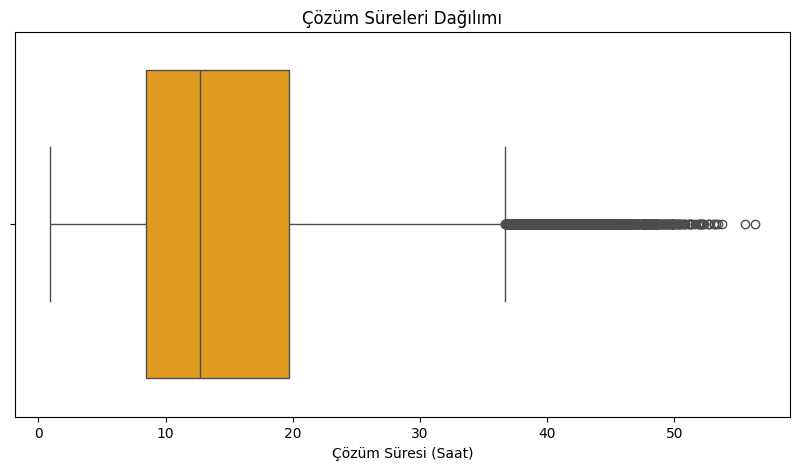

------------------------------------------------------------
Normal Kabul Edilen Üst Sınır: 36.66 Saat
Aykırı Toplam Vaka Sayısı: 970

--- AYKIRI VAKALARIN İLK 10'U ---


,min,max,Cozum_Suresi_Saat
Case ID,,,
INC24493,2023-01-27 23:54:00,2023-01-30 08:13:00,56.316667
INC30798,2023-02-24 00:41:00,2023-02-26 08:13:00,55.533333
INC26901,2023-03-19 19:58:00,2023-03-22 01:43:00,53.750000
INC23065,2023-12-17 15:33:00,2023-12-19 21:00:00,53.450000
INC13230,2023-06-15 20:44:00,2023-06-18 02:01:00,53.283333
INC25484,2023-01-11 12:36:00,2023-01-13 17:45:00,53.150000
INC30949,2023-11-26 22:04:00,2023-11-29 03:09:00,53.083333
INC9113,2023-10-25 19:01:00,2023-10-27 23:45:00,52.733333
INC3163,2023-03-30 19:52:00,2023-04-02 00:35:00,52.716667


In [37]:
#6.AYKIRI DEĞERLERİ TESPİT ETME VE İNCELEME

import matplotlib.pyplot as plt
import seaborn as sns

#verinin genel dağılımı için Boxplot ile gözlem
plt.figure(figsize=(10, 5))
sns.boxplot(x=sure_df['Cozum_Suresi_Saat'], color='orange')
plt.title('Çözüm Süreleri Dağılımı')
plt.xlabel('Çözüm Süresi (Saat)')
plt.show()

#İstatistiksel Sınırları Hesaplama (IQR Yöntemi)
Q1 = sure_df['Cozum_Suresi_Saat'].quantile(0.25)
Q3 = sure_df['Cozum_Suresi_Saat'].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

#aykırı kayıtları ayrı bir tabloya alma
aykirilar_df = sure_df[(sure_df['Cozum_Suresi_Saat'] < alt_sinir) | (sure_df['Cozum_Suresi_Saat'] > ust_sinir)]

aykirilar_sirali = aykirilar_df.sort_values(by='Cozum_Suresi_Saat', ascending=False)

print("-" * 60)
print(f"Normal Kabul Edilen Üst Sınır: {ust_sinir:.2f} Saat")
print(f"Aykırı Toplam Vaka Sayısı: {aykirilar_df.shape[0]}")
print("\n--- AYKIRI VAKALARIN İLK 10'U ---")
display(aykirilar_sirali.head(10))

In [38]:
#7.AYKIRI DEĞERLERİ TEMİZLEME VE ÖZELLİK ÇIKARIMI

pd.set_option('display.max_columns', None)

#aykırıları silme
sure_df_temiz = sure_df[(sure_df['Cozum_Suresi_Saat'] >= alt_sinir) & (sure_df['Cozum_Suresi_Saat'] <= ust_sinir)]

#kalanların ana bilgilerini filtreleme
saglikli_case_idler = sure_df_temiz.index
df_temiz = df[df['Case ID'].isin(saglikli_case_idler)]

# süreç özellikleri:1. step_count: bu arıza kaç işlem adımı sürmüş?
step_counts = df_temiz.groupby('Case ID').size().rename('Step_count')
# 2. reassignment_count: kaç farklı kişiye/gruba atanmış?
reassignment_counts = df_temiz.groupby('Case ID')['Resolver'].nunique().rename('Reassignment_count')
# 3. eskalasyon Sayısı (bir üst birime aktarılma durumları)
escalation_counts = df_temiz[df_temiz['Event'].astype(str).str.contains('escalat', case=False, na=False)].groupby('Case ID').size().rename('Escalation_count')
# 4. geri Dönme/sekme Sayısı (reddedilme veya müşteri tarafından yeniden açılma)
bounce_counts = df_temiz[df_temiz['Event'].astype(str).str.contains('reject|reopen', case=False, na=False)].groupby('Case ID').size().rename('Bounce_count')
#tekilleştirme
nihai_df = df_temiz.groupby('Case ID').agg({
    'Variant': 'first',
    'Priority': 'first',
    'Reporter': 'first',
    'Issue Type': 'first',
    'Resolver': 'first',
    'Report Channel': 'first',
    'Customer Satisfaction': 'first',
    'Timestamp': 'min'
})

#süreç özelliklerini tabloya birleştirme
nihai_df = nihai_df.join(step_counts)
nihai_df = nihai_df.join(reassignment_counts)
nihai_df = nihai_df.join(escalation_counts).fillna({'Escalation_count': 0})
nihai_df = nihai_df.join(bounce_counts).fillna({'Bounce_count': 0})

#zayıf olan Bounce_count'u binary (0 veya 1) formata çevirdik
nihai_df['Has_Bounce'] = (nihai_df['Bounce_count'] > 0).astype(int)

#işlem adımı ile atama sayısını çarparak eforu modelliyoruz
nihai_df['Workload_Index'] = nihai_df['Step_count'] * nihai_df['Reassignment_count']

#temiz Çözüm Süresi bilgisini tabloya ekleme
nihai_df = nihai_df.join(sure_df_temiz[['Cozum_Suresi_Saat']].rename(columns={'Cozum_Suresi_Saat': 'Resolution_Time_Hours'}))

#Açılış Günü ve Açılış Saati sütunları oluşturma
nihai_df['Open_Hour'] = nihai_df['Timestamp'].dt.hour
nihai_df['Open_Day'] = nihai_df['Timestamp'].dt.dayofweek # 0: Pazartesi, 6: Pazar

# hafta sonu kontrolü
nihai_df['Is_Weekend'] = nihai_df['Open_Day'].apply(lambda x: 1 if x >= 5 else 0)

nihai_df = nihai_df.drop('Timestamp', axis=1)

print("Aykırı değerler temizlendi ve süreç özellikleri üretildi.")
print("-" * 60)
print(f"Temiz Veri Seti Boyutu: {nihai_df.shape[0]} Vaka, {nihai_df.shape[1]} Özellik")
display(nihai_df.head())

Aykırı değerler temizlendi ve süreç özellikleri üretildi.
------------------------------------------------------------
Temiz Veri Seti Boyutu: 30618 Vaka, 17 Özellik


,Variant,Priority,Reporter,Issue Type,Resolver,Report Channel,Customer Satisfaction,Step_count,Reassignment_count,Escalation_count,Bounce_count,Has_Bounce,Workload_Index,Resolution_Time_Hours,Open_Hour,Open_Day,Is_Weekend
Case ID,,,,,,,,,,,,,,,,,
INC0001,Variant 4,Medium,Alice,Performance Issue,Unassigned,Website,3,7,5,1.0,0.0,0,35,10.183333,11,4,0
INC0002,Variant 3,High,Charlie,Performance Issue,Unassigned,App,3,8,5,1.0,0.0,0,40,5.716667,7,1,0
INC0003,Variant 9,High,Alice,Feature Request,Unassigned,Website,4,10,5,1.0,0.0,0,50,7.966667,19,3,0
INC0004,Variant 1,Medium,Bob,Incident,Unassigned,Email,4,6,3,0.0,0.0,0,18,9.566667,18,2,0
INC0005,Variant 3,Low,John,Performance Issue,Unassigned,Website,3,8,6,1.0,0.0,0,48,29.866667,12,1,0


In [39]:
#8.LABEL OLUŞTURMA

# öncelik durumuna göre dinamik SLA sınırları (Saat cinsinden) belirliyoruz
def sla_hesapla(row):
    if row['Priority'] == 'High':
        sinir = 8   # yüksek öncelikliler 8 saat
    elif row['Priority'] == 'Medium':
        sinir = 24  # orta öncelikliler 24 saat
    else:
        sinir = 48  # düşük öncelikliler 48 saat

    #çözüm süresi bu sınırı aştıysa SLA İhlali (1), aşmadıysa (0) döndür
    if row['Resolution_Time_Hours'] > sinir:
        return 1
    else:
        return 0

#hedef değişken sütununu oluşturma
nihai_df['SLA_Violation'] = nihai_df.apply(sla_hesapla, axis=1)

print("'SLA_Violation' (1 ve 0) hedef değişkeni eklendi.")
print("-" * 60)
print(nihai_df['SLA_Violation'].value_counts())

# Data Leakage ve Overfitting engellemek için riskli sütunları çıkarma
nihai_df_export = nihai_df.drop([
    'Resolution_Time_Hours',
    'Open_Day',
    'Customer Satisfaction',
    'Reporter',
    'Resolver',
    'Bounce_count'
], axis=1, errors='ignore')

'SLA_Violation' (1 ve 0) hedef değişkeni eklendi.
------------------------------------------------------------
SLA_Violation
0    29395
1     1223
Name: count, dtype: int64


In [19]:
# event sütunundakikelimeler::
print(df['Event'].value_counts())

Event
Ticket closed                           11049
WIP - level 1 support                   10904
Ticket created                          10643
Ticket assigned to level 1 support      10514
Customer feedback received              10266
WIP - level 2 support                    7482
Ticket solved by level 2 support         6500
Level 1 escalates to level 2 support     6191
Ticket solved by level 1 support         3820
Ticket assigned to level 2 support       1192
WIP - level 3 support                    1090
Level 2 escalates to level 3 support     1090
Ticket reopened by customer               407
Ticket rejected by level 1 support        291
Ticket solved by level 3 support          238
Ticket escalated to level 2 support       212
Level 2 support rejects the ticket        200
                                            1
Name: count, dtype: int64


In [40]:

print("\n 1. KONTROL: Veri Tipleri ve Eksik Veri Durumu")
nihai_df_export.info()

print("\n 2. KONTROL: Eklenen Süreç Özelliklerinin İstatistikleri")
display(nihai_df_export[['Step_count', 'Reassignment_count', 'Escalation_count', 'Has_Bounce']].describe())

print("\n 3. KONTROL: YSA'nın Göreceği Nihai Tablonun İlk 5 Satırı")
display(nihai_df_export.head())
print("-" * 60)
# -------------------------------------------------------


 1. KONTROL: Veri Tipleri ve Eksik Veri Durumu
<class 'pandas.core.frame.DataFrame'>
Index: 30618 entries, INC0001 to INC9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Variant             30618 non-null  object 
 1   Priority            30618 non-null  object 
 2   Issue Type          30618 non-null  object 
 3   Report Channel      30618 non-null  object 
 4   Step_count          30618 non-null  int64  
 5   Reassignment_count  30618 non-null  int64  
 6   Escalation_count    30618 non-null  float64
 7   Has_Bounce          30618 non-null  int64  
 8   Workload_Index      30618 non-null  int64  
 9   Open_Hour           30618 non-null  int32  
 10  Is_Weekend          30618 non-null  int64  
 11  SLA_Violation       30618 non-null  int64  
dtypes: float64(1), int32(1), int64(6), object(4)
memory usage: 2.9+ MB

 2. KONTROL: Eklenen Süreç Özelliklerinin İstatistikleri


,Step_count,Reassignment_count,Escalation_count,Has_Bounce
count,30618.000000,30618.000000,30618.000000,30618.000000
mean,7.532367,3.845516,0.667973,0.080214
std,2.011451,1.305648,0.661430,0.271629
min,4.000000,2.000000,0.000000,0.000000
25%,6.000000,3.000000,0.000000,0.000000
50%,8.000000,4.000000,1.000000,0.000000
75%,8.000000,5.000000,1.000000,0.000000
max,15.000000,10.000000,3.000000,1.000000



 3. KONTROL: YSA'nın Göreceği Nihai Tablonun İlk 5 Satırı


,Variant,Priority,Issue Type,Report Channel,Step_count,Reassignment_count,Escalation_count,Has_Bounce,Workload_Index,Open_Hour,Is_Weekend,SLA_Violation
Case ID,,,,,,,,,,,,
INC0001,Variant 4,Medium,Performance Issue,Website,7,5,1.0,0,35,11,0,0
INC0002,Variant 3,High,Performance Issue,App,8,5,1.0,0,40,7,0,0
INC0003,Variant 9,High,Feature Request,Website,10,5,1.0,0,50,19,0,0
INC0004,Variant 1,Medium,Incident,Email,6,3,0.0,0,18,18,0,0
INC0005,Variant 3,Low,Performance Issue,Website,8,6,1.0,0,48,12,0,0


------------------------------------------------------------


In [42]:
csv_isim = 'SLA_Temiz_Veri.csv'
nihai_df_export.to_csv(csv_isim, index=True)
print(f"\n✅ {csv_isim} başarıyla oluşturuldu!.")


✅ SLA_Temiz_Veri.csv başarıyla oluşturuldu!.


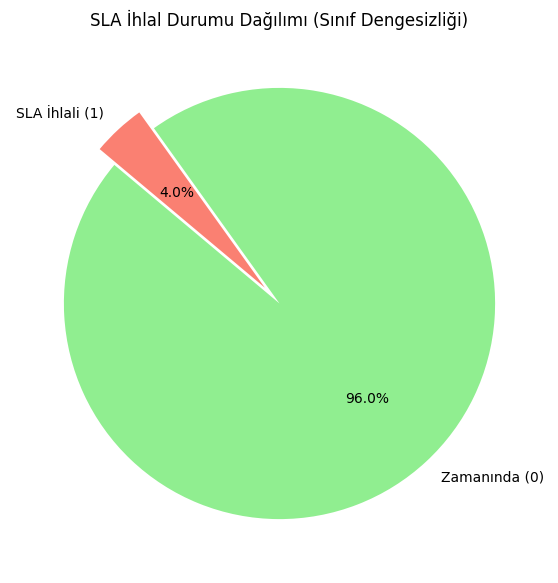

/tmp/ipykernel_1246/2817695668.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Priority', y='Resolution_Time_Hours', data=nihai_df, order=order, palette='viridis')


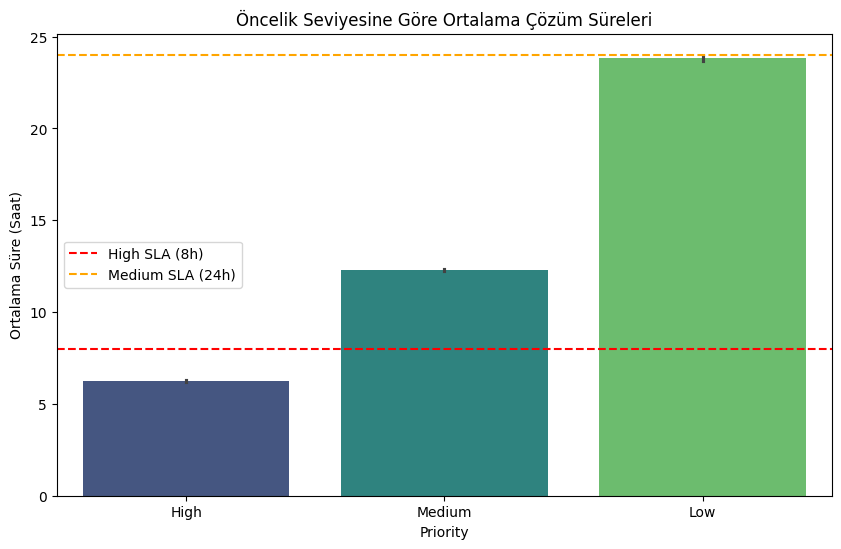

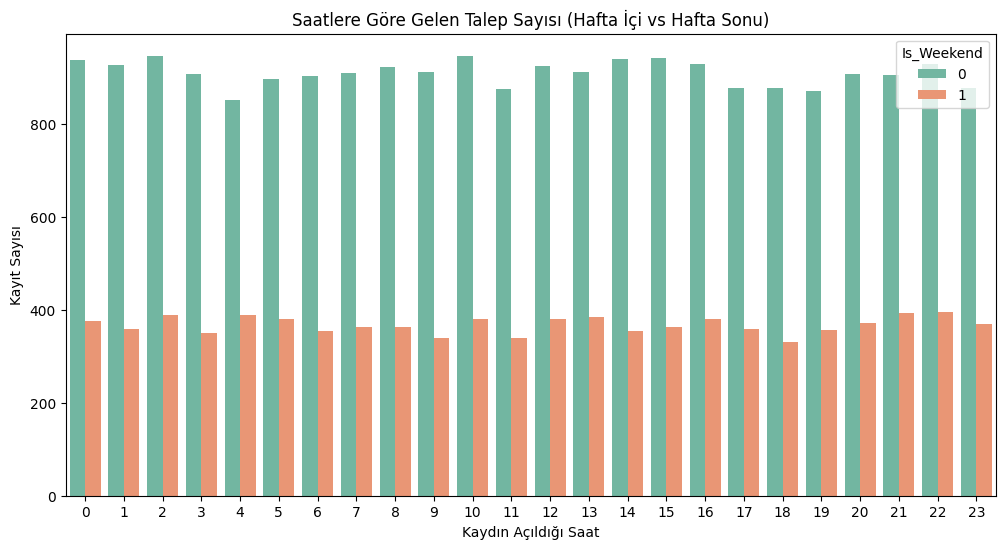

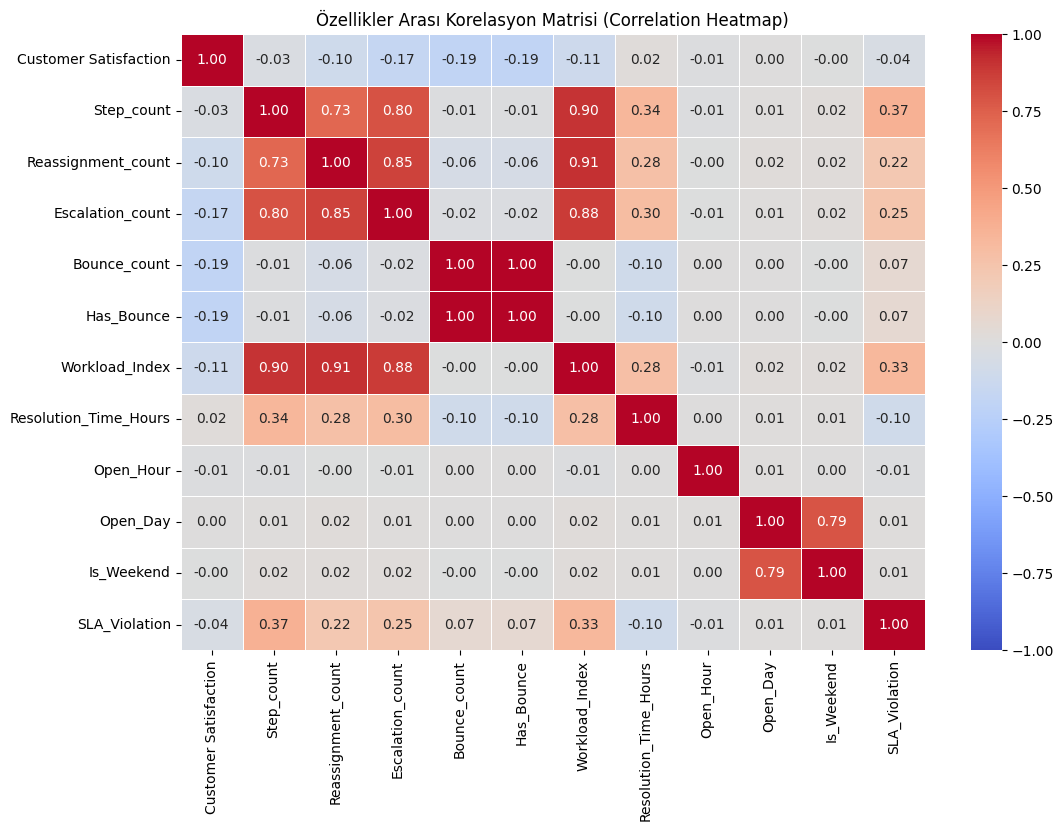

/tmp/ipykernel_1246/2817695668.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SLA_Violation', y='Step_count', data=nihai_df, palette='Set1')


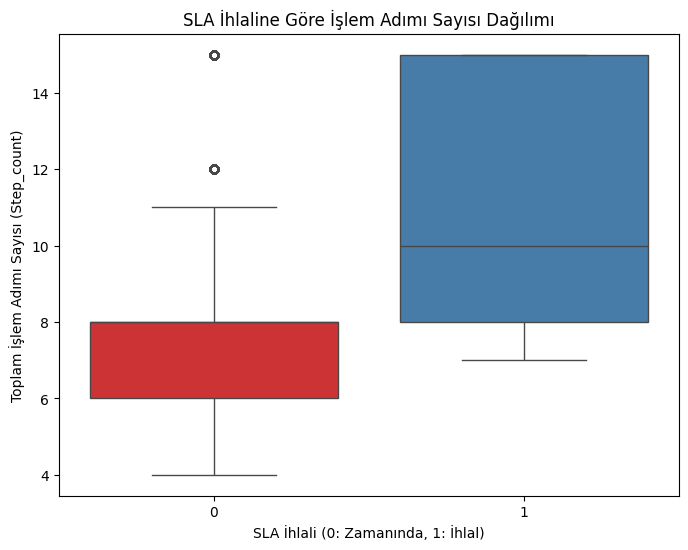

/tmp/ipykernel_1246/2817695668.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Escalation_count', y='SLA_Violation', data=nihai_df, palette='Reds', errorbar=None)


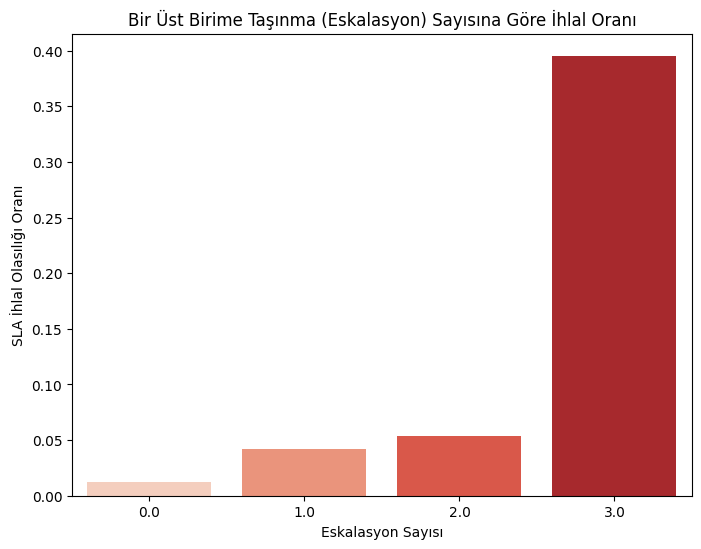

In [43]:
#ANALİZ GRAFİKLERİ

import matplotlib.pyplot as plt
import seaborn as sns

# SLA İhlal Oranı Grafiği: sınıf dengesizliğini gösteriyor.
plt.figure(figsize=(7, 7))
target_counts = nihai_df['SLA_Violation'].value_counts()
labels = ['Zamanında (0)', 'SLA İhlali (1)']
colors = ['lightgreen', 'salmon']
plt.pie(target_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0, 0.1))
plt.title('SLA İhlal Durumu Dağılımı (Sınıf Dengesizliği)')
plt.show()

# Önceliğe Göre Ortalama Çözüm Süresi (Bar Chart): belirlediğimiz 8-24-48 saatlik sınırlarının mantığı.
plt.figure(figsize=(10, 6))
order = ['High', 'Medium', 'Low']
sns.barplot(x='Priority', y='Resolution_Time_Hours', data=nihai_df, order=order, palette='viridis')
plt.axhline(8, color='red', linestyle='--', label='High SLA (8h)')
plt.axhline(24, color='orange', linestyle='--', label='Medium SLA (24h)')
plt.title('Öncelik Seviyesine Göre Ortalama Çözüm Süreleri')
plt.ylabel('Ortalama Süre (Saat)')
plt.legend()
plt.show()

#Günlük Yoğunluk Analizi (Count Plot): Kayıtların en çok hangi saatlerde açıldığının gösterimi.
plt.figure(figsize=(12, 6))
sns.countplot(x='Open_Hour', data=nihai_df, hue='Is_Weekend', palette='Set2')
plt.title('Saatlere Göre Gelen Talep Sayısı (Hafta İçi vs Hafta Sonu)')
plt.xlabel('Kaydın Açıldığı Saat')
plt.ylabel('Kayıt Sayısı')
plt.show()

#Korelasyon Isı Haritası
plt.figure(figsize=(12, 8))
numeric_cols = nihai_df.select_dtypes(include=['int64', 'float64', 'int32']).columns
sns.heatmap(nihai_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Özellikler Arası Korelasyon Matrisi (Correlation Heatmap)')
plt.show()

# SLA İhlali ile İşlem Adımı Sayısı (Step_count) Arasındaki İlişki
plt.figure(figsize=(8, 6))
sns.boxplot(x='SLA_Violation', y='Step_count', data=nihai_df, palette='Set1')
plt.title('SLA İhlaline Göre İşlem Adımı Sayısı Dağılımı')
plt.xlabel('SLA İhlali (0: Zamanında, 1: İhlal)')
plt.ylabel('Toplam İşlem Adımı Sayısı (Step_count)')
plt.show()

# Eskalasyon Sayısının SLA İhlaline Doğrudan Etkisi
plt.figure(figsize=(8, 6))
sns.barplot(x='Escalation_count', y='SLA_Violation', data=nihai_df, palette='Reds', errorbar=None)
plt.title('Bir Üst Birime Taşınma (Eskalasyon) Sayısına Göre İhlal Oranı')
plt.xlabel('Eskalasyon Sayısı')
plt.ylabel('SLA İhlal Olasılığı Oranı')
plt.show()